In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
print("\nData Types")
print(df.dtypes)
print("\nFirst 5 Rows")
df.head()

Shape: (7043, 21)

Data Types
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

First 5 Rows


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("Duplicates:", df.duplicated().sum())
print("\nMissing Values")
print(df.isnull().sum())

print("\nNon-numeric values in TotalCharges")
print(df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()]['TotalCharges'].value_counts())

Duplicates: 0

Missing Values
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Non-numeric values in TotalCharges
TotalCharges
    11
Name: count, dtype: int64


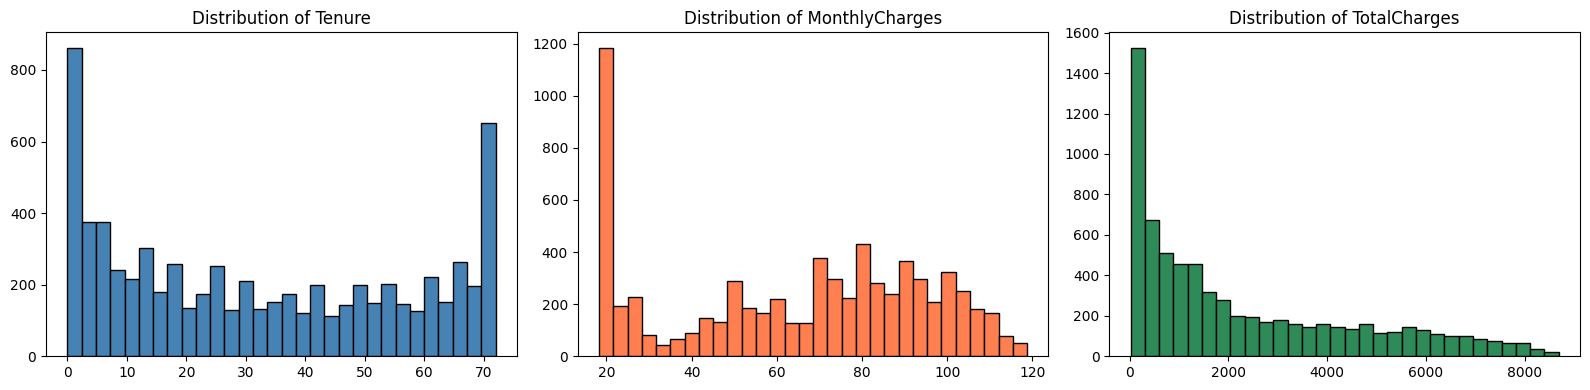

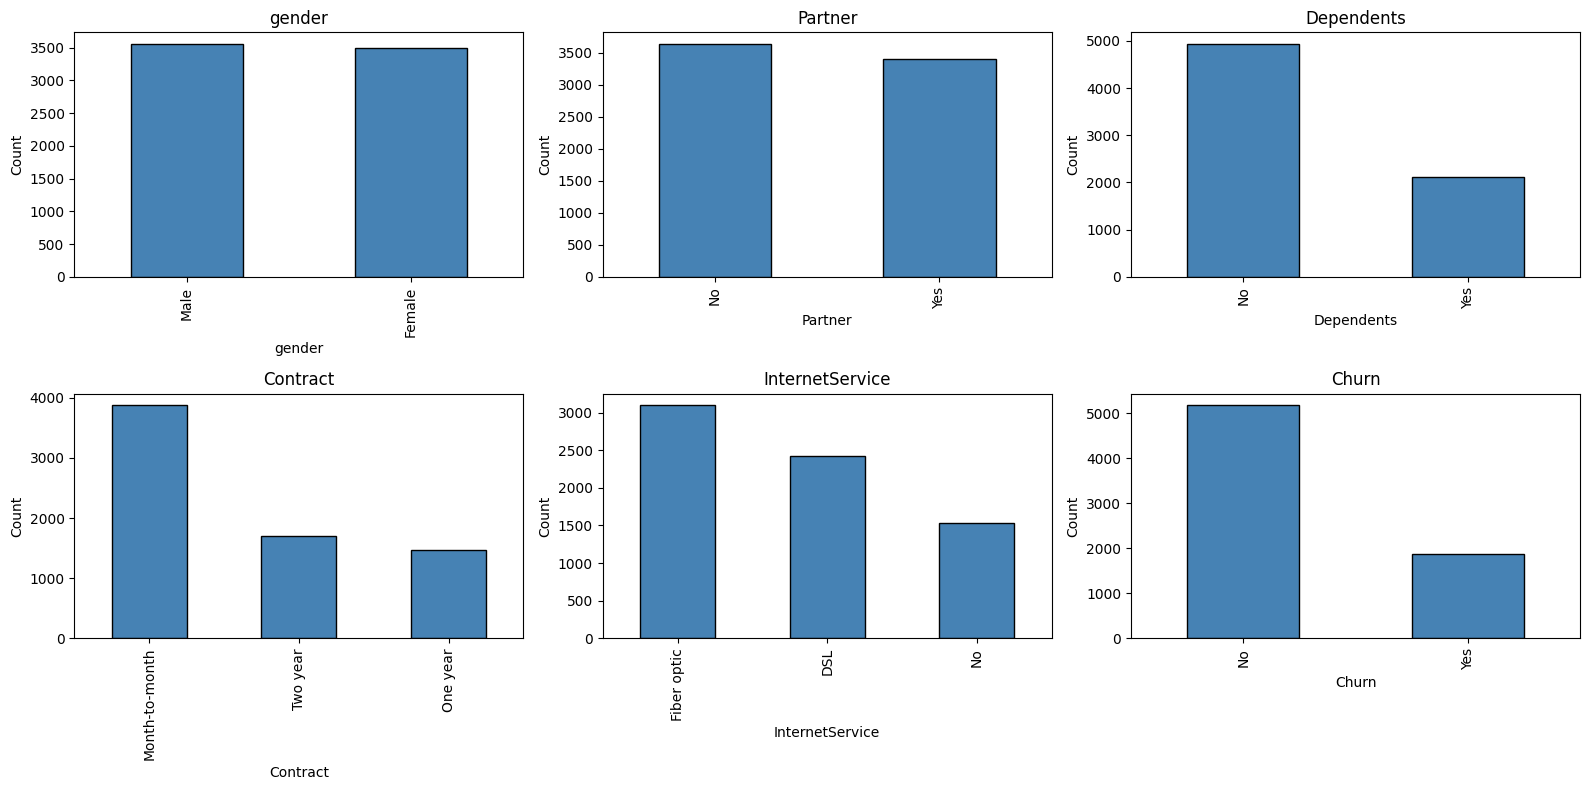

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['tenure'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Tenure')

axes[1].hist(df['MonthlyCharges'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Distribution of MonthlyCharges')

axes[2].hist(df['TotalCharges'].dropna(), bins=30, color='seagreen', edgecolor='black')
axes[2].set_title('Distribution of TotalCharges')

plt.tight_layout()
plt.show()

cat_cols = ['gender', 'Partner', 'Dependents', 'Contract', 'InternetService', 'Churn']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, col in zip(axes.flatten(), cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

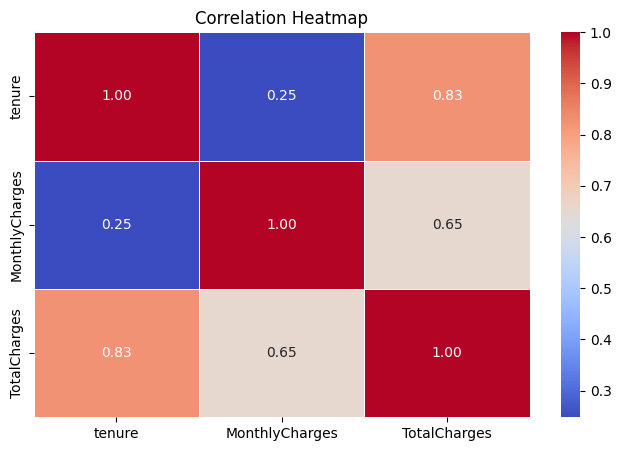

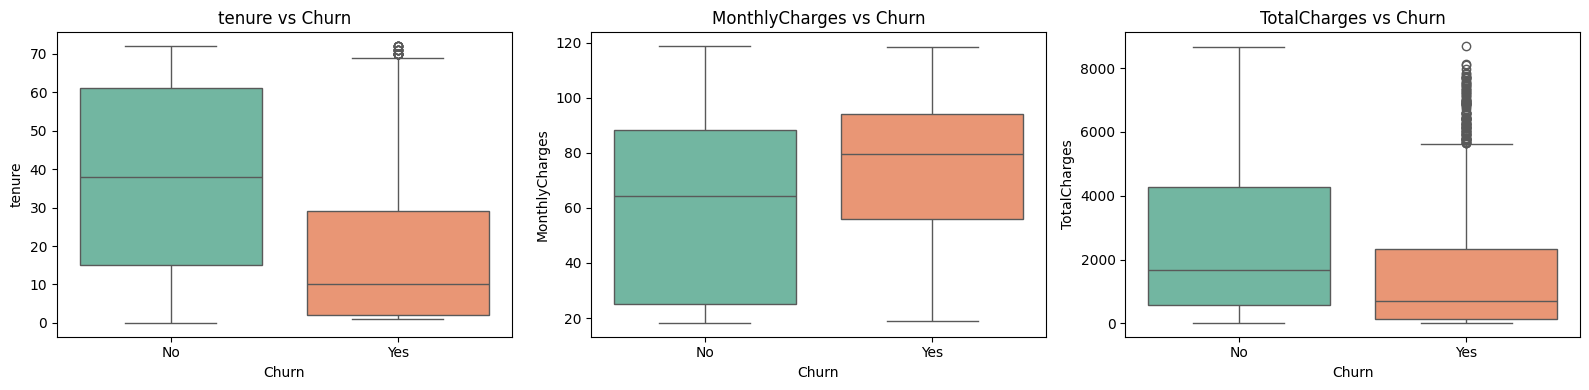

In [4]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(8, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(x='Churn', y=col, data=df, ax=ax, palette='Set2')
    ax.set_title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right;">


در بررسی اولیه مشخص شد که ۱۱ سطر از  TotalCharges دارای مقدار نامعتبر هستند. پس از تبدیل آن‌ها به NaN، برای پر کردن آن‌ها از میانه استفاده کردیم

با توجه به نمودارهای فاز قبل توزیع ویژگی TotalCharges چوله به راست است. در چنین توزیع‌هایی میانگین تحت تاثیر مقادیر بزرگ و پرت قرار می‌گیرد و معیار مرکزی خوبی نیست. اما میانه نسبت به نقاط پرت مقاوم است. همچنین از آنجا که تنها 11 سطر گم‌شده بودند این انتخاب کمترین انحراف را در توزیع اصلی داده‌ها ایجاد می‌کند.

</div>

In [5]:
print("Missing before fix:", df['TotalCharges'].isnull().sum())

df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print("Missing after fix:", df['TotalCharges'].isnull().sum())

df.drop('customerID', axis=1, inplace=True)

from sklearn.preprocessing import LabelEncoder, StandardScaler

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print("\nShape after preprocessing:", df.shape)
print("\nFirst 3 rows")
df.head(3)

Missing before fix: 11
Missing after fix: 0

Shape after preprocessing: (7043, 31)

--- First 3 rows ---


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,-1.160323,-0.994242,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.066327,1,0,-0.259629,-0.173244,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,-1.236724,1,1,-0.362660,-0.959674,1,...,False,False,False,False,False,False,False,False,False,True


In [6]:
df_raw = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')
df_raw['TotalCharges'].fillna(df_raw['TotalCharges'].median(), inplace=True)

df['AvgChargePerMonth'] = df_raw['TotalCharges'] / (df_raw['tenure'] + 1)
df['TenureGroup'] = pd.cut(df_raw['tenure'], bins=[-1, 12, 24, 48, 72], labels=[0, 1, 2, 3]).astype(int)

print("New features added")
print("Shape:", df.shape)
print(df[['AvgChargePerMonth', 'TenureGroup']].head())

New features added!
Shape: (7043, 33)
   AvgChargePerMonth  TenureGroup
0          14.925000            0
1          53.985714            2
2          36.050000            0
3          40.016304            2
4          50.550000            0


ANOVA F-Test (Top 15)
tenure                                  997.268010
TenureGroup                             953.850910
InternetService_Fiber optic             738.046042
Contract_Two year                       707.919254
PaymentMethod_Electronic check          706.195028
InternetService_No                      385.698588
OnlineBackup_No internet service        385.698588
OnlineSecurity_No internet service      385.698588
DeviceProtection_No internet service    385.698588
StreamingTV_No internet service         385.698588
TechSupport_No internet service         385.698588
StreamingMovies_No internet service     385.698588
TotalCharges                            290.439831
MonthlyCharges                          273.463704
PaperlessBilling                        268.985218
dtype: float64

Random Forest Importance (Top 15)
TotalCharges                      0.145602
AvgChargePerMonth                 0.132635
MonthlyCharges                    0.132491
tenure                            

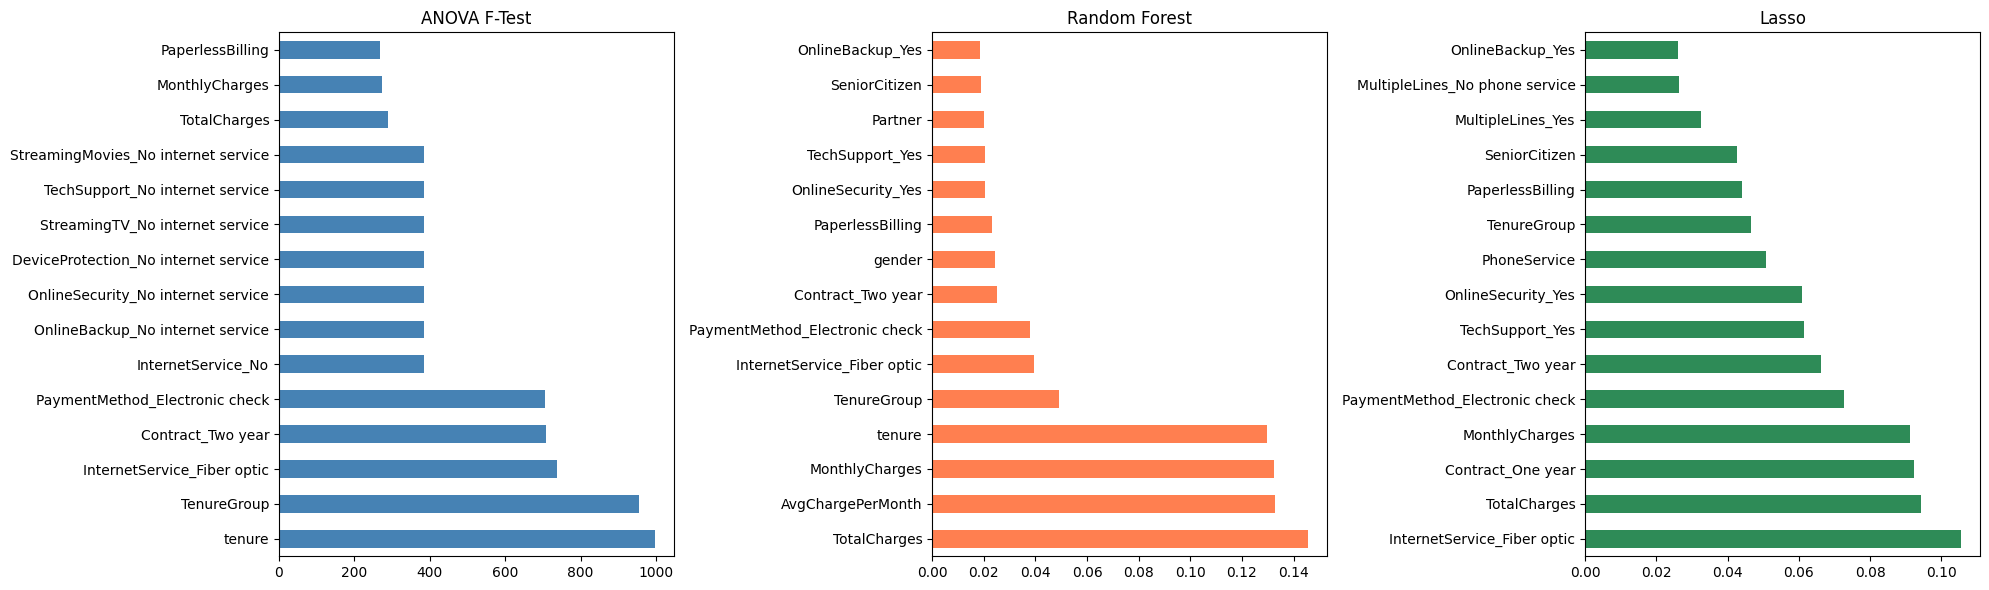

In [7]:
from sklearn.feature_selection import chi2, f_classif, SelectKBest
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso

X = df.drop('Churn', axis=1)
y = df['Churn']

selector_anova = SelectKBest(score_func=f_classif, k='all')
selector_anova.fit(X, y)
anova_scores = pd.Series(selector_anova.scores_, index=X.columns).sort_values(ascending=False)

print("ANOVA F-Test (Top 15)")
print(anova_scores.head(15))

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nRandom Forest Importance (Top 15)")
print(rf_importance.head(15))

lasso = Lasso(alpha=0.001, random_state=42)
lasso.fit(X, y)
lasso_importance = pd.Series(abs(lasso.coef_), index=X.columns).sort_values(ascending=False)

print("\nLasso Importance (Top 15)")
print(lasso_importance.head(15))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

anova_scores.head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('ANOVA F-Test')

rf_importance.head(15).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Random Forest')

lasso_importance.head(15).plot(kind='barh', ax=axes[2], color='seagreen')
axes[2].set_title('Lasso')

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right;">

برای انتخاب بهترین ویژگی‌ها از ترکیب سه روش مختلف استفاده کردیم تا از bias یک روش خاص جلوگیری کنیم:
1. آزمون آماری ANOVA: برای بررسی رابطه خطی و مستقل هر ویژگی با متغیر ریزش مشتری
2. مدل Random Forest: برای شناسایی روابط غیرخطی و ارتباطات بین ویژگی‌ها
3. مدل رگرسیون Lasso: برای حذف ویژگی‌های تکراری و انتخاب قوی‌ترین پیش‌بینی‌کننده‌ها با صفر کردن ضرایب اضافی.

دلیل انتخاب زیرمجموعه نهایی:
ویژگی‌هایی به عنوان زیرمجموعه نهایی انتخاب شدند که در خروجی هر سه روش، بیشترین اهمیت را داشتند. متغیرهایی مانند نوع قرارداد، مدت زمان ماندگاری (tenure) و هزینه‌ها در تمامی روش‌ها رتبه بالایی داشتند. این کار تضمین می‌کند که ویژگی‌های نهایی قوی‌ترین سیگنال‌ها را برای پیش‌بینی دارند و از overfitting مدل به دلیل وجود داده‌های نویز جلوگیری می‌شود.

</div>

In [8]:
selected_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'TenureGroup', 'AvgChargePerMonth', 'InternetService_Fiber optic', 'Contract_Two year', 'Contract_One year', 'PaymentMethod_Electronic check', 'PaperlessBilling', 'OnlineSecurity_Yes', 'TechSupport_Yes', 'OnlineBackup_Yes', 'SeniorCitizen']

X = df[selected_features]
y = df['Churn']

print("Selected features:", len(selected_features))
print(selected_features)

Selected features: 14
['tenure', 'MonthlyCharges', 'TotalCharges', 'TenureGroup', 'AvgChargePerMonth', 'InternetService_Fiber optic', 'Contract_Two year', 'Contract_One year', 'PaymentMethod_Electronic check', 'PaperlessBilling', 'OnlineSecurity_Yes', 'TechSupport_Yes', 'OnlineBackup_Yes', 'SeniorCitizen']


In [9]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score
from imblearn.over_sampling import SMOTE
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42)
}

print("\nResults with SMOTE")
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    recall = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"{name:25s}  Recall: {recall:.4f}  AUC: {auc:.4f}")

print("\nResults with Class Weights (no SMOTE)")
weighted_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42)
}

for name, model in weighted_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    recall = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"{name:25s}  Recall: {recall:.4f}  AUC: {auc:.4f}")

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}

Results with SMOTE
Logistic Regression        Recall: 0.7353  AUC: 0.8302
KNN                        Recall: 0.6898  AUC: 0.7626
Random Forest              Recall: 0.6096  AUC: 0.8062
Gradient Boosting          Recall: 0.7326  AUC: 0.8354

Results with Class Weights (no SMOTE)
Logistic Regression        Recall: 0.7941  AUC: 0.8417
Random Forest              Recall: 0.4840  AUC: 0.8151
Gradient Boosting          Recall: 0.5214  AUC: 0.8389


In [10]:
from sklearn.ensemble import VotingClassifier

lr = LogisticRegression(max_iter=1000, random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
rf = RandomForestClassifier(n_estimators=200, random_state=42)

voting = VotingClassifier(estimators=[('lr', lr), ('gb', gb), ('rf', rf)], voting='soft')
voting.fit(X_train_sm, y_train_sm)
y_pred_vote = voting.predict(X_test)
recall_vote = recall_score(y_test, y_pred_vote)
auc_vote = roc_auc_score(y_test, voting.predict_proba(X_test)[:, 1])
print(f"Voting Classifier | Recall: {recall_vote:.4f} | AUC: {auc_vote:.4f}")

print("\nGridSearch: Logistic Regression")
param_lr = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_lr, scoring='recall', cv=StratifiedKFold(5), n_jobs=-1)
grid_lr.fit(X_train_sm, y_train_sm)
print("Best params:", grid_lr.best_params_)
print("Best Recall:", round(grid_lr.best_score_, 4))

print("\nGridSearch: Gradient Boosting")
param_gb = {'n_estimators': [100, 200, 300], 'learning_rate': [0.05, 0.1, 0.2], 'max_depth': [3, 5]}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_gb, scoring='recall', cv=StratifiedKFold(5), n_jobs=-1)
grid_gb.fit(X_train_sm, y_train_sm)
print("Best params:", grid_gb.best_params_)
print("Best Recall:", round(grid_gb.best_score_, 4))

Voting Classifier | Recall: 0.6979 | AUC: 0.8336

GridSearch: Logistic Regression
Best params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Recall: 0.7698

GridSearch: Gradient Boosting
Best params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
Best Recall: 0.8336


In [11]:
best_lr = grid_lr.best_estimator_
best_gb = grid_gb.best_estimator_

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Stratified K-Fold Cross Validation (on SMOTE data)\n")

lr_scores = cross_val_score(best_lr, X_train_sm, y_train_sm, cv=skf, scoring='recall')
print(f"Logistic Regression  Mean Recall: {lr_scores.mean():.4f}  Std: {lr_scores.std():.4f}")

gb_scores = cross_val_score(best_gb, X_train_sm, y_train_sm, cv=skf, scoring='recall')
print(f"Gradient Boosting    Mean Recall: {gb_scores.mean():.4f}  Std: {gb_scores.std():.4f}")

rf_scores = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=42), X_train_sm, y_train_sm, cv=skf, scoring='recall')
print(f"Random Forest        Mean Recall: {rf_scores.mean():.4f}  Std: {rf_scores.std():.4f}")

voting_scores = cross_val_score(voting, X_train_sm, y_train_sm, cv=skf, scoring='recall')
print(f"Voting Classifier    Mean Recall: {voting_scores.mean():.4f}  Std: {voting_scores.std():.4f}")

Stratified K-Fold Cross Validation (on SMOTE data)

Logistic Regression  Mean Recall: 0.7714  Std: 0.0134
Gradient Boosting    Mean Recall: 0.8374  Std: 0.0066
Random Forest        Mean Recall: 0.8512  Std: 0.0048
Voting Classifier    Mean Recall: 0.8488  Std: 0.0072


In [12]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, RocCurveDisplay
all_models = {'Logistic Regression': best_lr, 'Gradient Boosting': best_gb, 'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42).fit(X_train_sm, y_train_sm), 'Voting Classifier': voting}
print("Final Metrics on Test Set\n")
for name, model in all_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    print(f"{name}  Acc: {acc:.4f}  Prec: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}")

Final Metrics on Test Set

Logistic Regression  Acc: 0.7452  Prec: 0.5140  Recall: 0.7353  F1: 0.6051  AUC: 0.8302
Gradient Boosting  Acc: 0.7601  Prec: 0.5400  Recall: 0.6497  F1: 0.5898  AUC: 0.8235
Random Forest  Acc: 0.7587  Prec: 0.5403  Recall: 0.6096  F1: 0.5729  AUC: 0.8062
Voting Classifier  Acc: 0.7537  Prec: 0.5273  Recall: 0.6979  F1: 0.6007  AUC: 0.8336


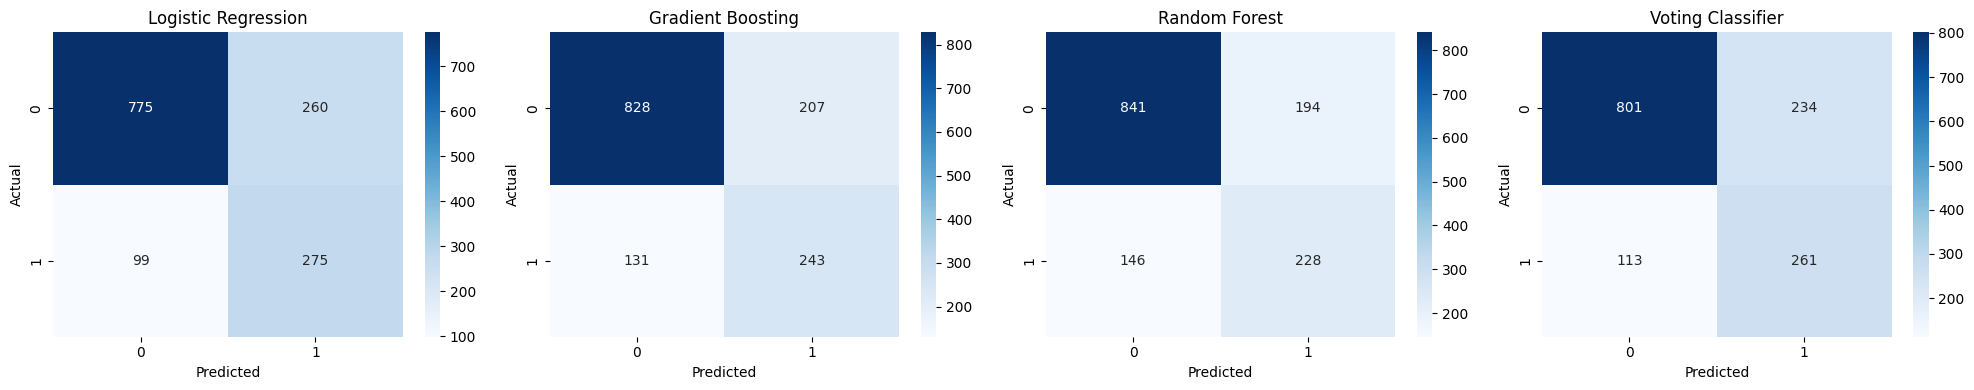

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, model) in zip(axes, all_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

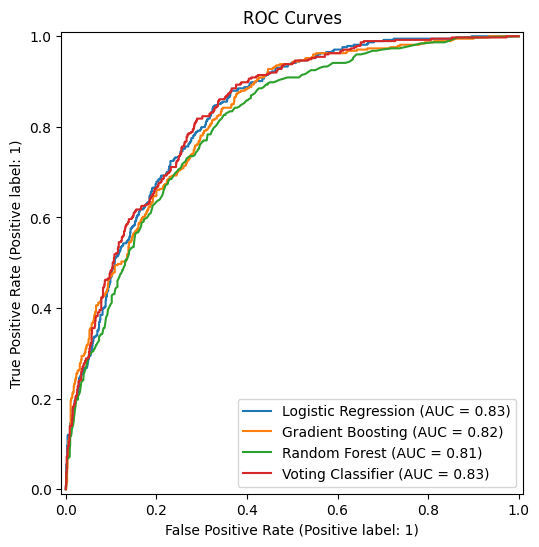

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, model in all_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title('ROC Curves')
plt.show()

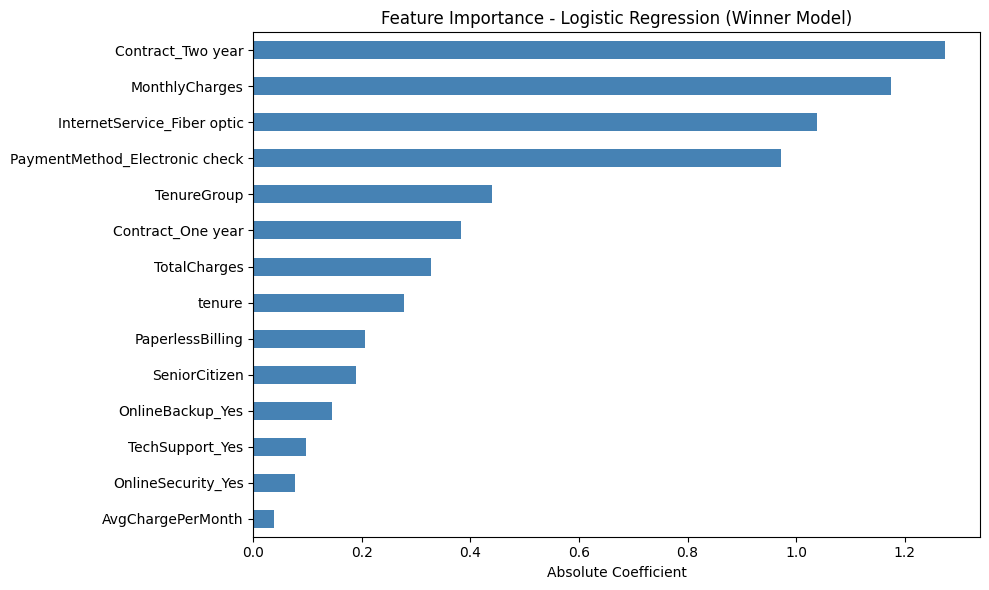

In [15]:
importance = pd.Series(abs(best_lr.coef_[0]), index=selected_features).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Logistic Regression (Winner Model)')
plt.xlabel('Absolute Coefficient')
plt.tight_layout()
plt.show()

In [106]:
import numpy as np

y_proba = best_lr.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.01)

best_threshold = 0.5
max_recall = 0
best_f1 = 0

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    rec = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    if f1 >= 0.50 and rec > max_recall:
        max_recall = rec
        best_threshold = t
        best_f1 = f1

print("Bonus Challenge (threshold optimization)")
print(f"Optimal Threshold: {best_threshold:.2f}")
print(f"Maximized Recall:  {max_recall:.4f}")
print(f"Maintained F1:     {best_f1:.4f}")

Bonus Challenge (threshold optimization)
Optimal Threshold: 0.12
Maximized Recall:  0.9893
Maintained F1:     0.5041


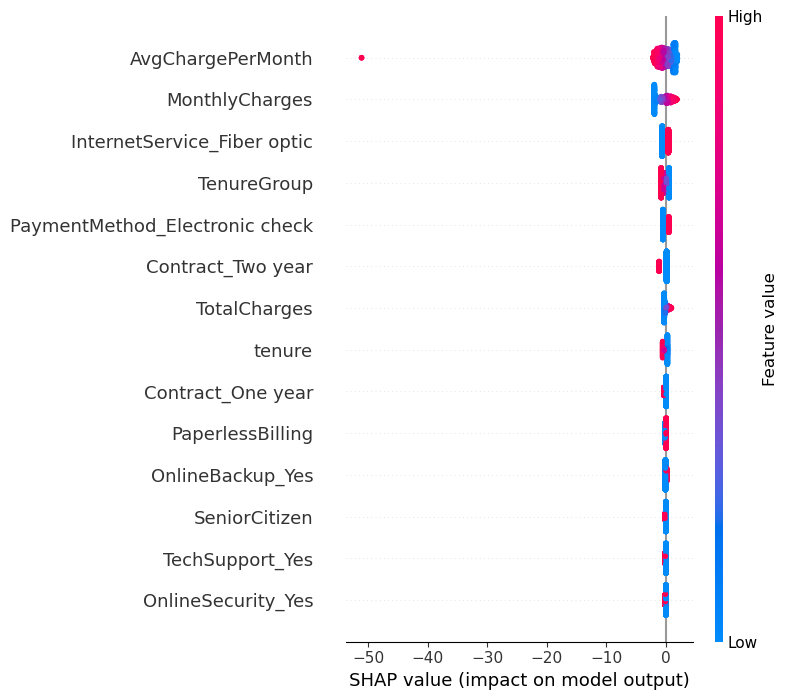

In [112]:
import shap

explainer = shap.LinearExplainer(best_lr, X_train_sm)
shap_values = explainer.shap_values(X_test)

shap_values = np.array(shap_values, dtype=np.float64)
X_test_array = np.array(X_test, dtype=np.float64)

shap.summary_plot(shap_values, X_test_array, feature_names=selected_features)

<div dir="rtl" style="text-align: right;">

مدل برنده: Logistic Regression با بهینه‌سازی آستانه تصمیم‌گیری، بالاترین Recall (حدود 0.99) را با حفظ F1 بالای 0.50 به دست آورد.

مهم‌ترین ویژگی‌های اثرگذار بر ریزش مشتری:
1. نوع قرارداد: مشتریان با قرارداد ماهانه بیشترین ریزش را دارند.
2. هزینه ماهانه: هرچه هزینه بالاتر باشد احتمال ریزش بیشتر است.
3. اینترنت فیبر نوری: مشتریان این سرویس نرخ ریزش بالاتری دارند.
4. روش پرداخت الکترونیکی: این روش پرداخت با ریزش بیشتر همراه است.
5. مدت ماندگاری: مشتریان جدید بیشتر ریزش می‌کنند.

پیشنهادات تجاری:
1. ارائه تخفیف یا مزایای ویژه به مشتریان با قرارداد ماهانه برای تشویق به قرارداد بلندمدت.
2. بازبینی قیمت‌گذاری سرویس فیبر نوری یا افزایش کیفیت آن متناسب با هزینه.
3. ارائه پشتیبانی فنی و امنیت آنلاین رایگان به مشتریان جدید (tenure کمتر از ۱۲ ماه) برای افزایش رضایت اولیه.

</div>